In [308]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import sparse
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

In [309]:

#LOAD Loan_Default.csv


df = pd.read_csv("/kaggle/input/datasets/shanakakalubowilage/loan-dataset/Loan_Default.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


MEMBER 1 - SHANAKA - STAGE 3
* DATASET STRUCTURE, TYPES, DESCRIPTIVE STATISTICS AND DISTRIBUTIONS

In [310]:
# 1. DATASET DIMENSIONS
print("Number of rows :", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows : 148670
Number of columns: 34


In [311]:
# 2. VIEW RECORDS
display(df.head())

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [312]:
# 3. COLUMN NAMES
for number, column in enumerate(df.columns, start=1):
 print(f"{number}. {column}")

1. ID
2. year
3. loan_limit
4. Gender
5. approv_in_adv
6. loan_type
7. loan_purpose
8. Credit_Worthiness
9. open_credit
10. business_or_commercial
11. loan_amount
12. rate_of_interest
13. Interest_rate_spread
14. Upfront_charges
15. term
16. Neg_ammortization
17. interest_only
18. lump_sum_payment
19. property_value
20. construction_type
21. occupancy_type
22. Secured_by
23. total_units
24. income
25. credit_type
26. Credit_Score
27. co-applicant_credit_type
28. age
29. submission_of_application
30. LTV
31. Region
32. Security_Type
33. Status
34. dtir1


In [313]:
# 4. DATASET INFORMATION
# Shows data types, non-null counts and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [314]:
# 5. NUMERICAL AND CATEGORICAL FEATURES
numerical_columns = (
 df.select_dtypes(include=["number"])
 .columns
 .tolist()
)
categorical_columns = (
 df.select_dtypes(include=["object", "category"])
 .columns
 .tolist()
)
print("Numerical columns:")
print(numerical_columns)
print("Number of numerical columns:", len(numerical_columns))
print("\nCategorical columns:")
print(categorical_columns)
print("Number of categorical columns:", len(categorical_columns))

Numerical columns:
['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'Status', 'dtir1']
Number of numerical columns: 13

Categorical columns:
['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']
Number of categorical columns: 21


In [315]:
# 6. VARIABLE TYPE SUMMARY
# Useful for identifying identifiers, binary variables and high-cardinality features.
type_summary = pd.DataFrame({
 "Column": df.columns,
 "Data_Type": df.dtypes.astype(str).values,
 "Unique_Values": [df[c].nunique(dropna=False) for c in df.columns],
 "Missing_Values": [df[c].isna().sum() for c in df.columns]
})
display(type_summary)

,Column,Data_Type,Unique_Values,Missing_Values
0,ID,int64,148670,0
1,year,int64,1,0
2,loan_limit,object,3,3344
3,Gender,object,4,0
4,approv_in_adv,object,3,908
5,loan_type,object,3,0
6,loan_purpose,object,5,134
7,Credit_Worthiness,object,2,0
8,open_credit,object,2,0
9,business_or_commercial,object,2,0


In [316]:
# 7. NUMERICAL DESCRIPTIVE STATISTICS
# count, mean, standard deviation, min, quartiles and max.
numerical_summary = df.describe().T
display(numerical_summary)

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


In [317]:
# 8. CATEGORICAL DESCRIPTIVE STATISTICS
# count, number of categories, most frequent category and its frequency.
categorical_summary = df.describe(include=["object"]).T
display(categorical_summary)

,count,unique,top,freq
loan_limit,145326,2,cf,135348
Gender,148670,4,Male,42346
approv_in_adv,147762,2,nopre,124621
loan_type,148670,3,type1,113173
loan_purpose,148536,4,p3,55934
Credit_Worthiness,148670,2,l1,142344
open_credit,148670,2,nopc,148114
business_or_commercial,148670,2,nob/c,127908
Neg_ammortization,148549,2,not_neg,133420
interest_only,148670,2,not_int,141560


In [318]:
# 9. UNIQUE VALUES
unique_counts = df.nunique(dropna=False).sort_values()
display(unique_counts.to_frame("Unique_Count"))

,Unique_Count
year,1
Credit_Worthiness,2
business_or_commercial,2
open_credit,2
Secured_by,2
construction_type,2
lump_sum_payment,2
interest_only,2
co-applicant_credit_type,2
Security_Type,2


In [319]:
# 10. CONSTANT COLUMNS
# A constant feature has the same value for all records and gives no predictive variation.
constant_columns = [
 c for c in df.columns
 if df[c].nunique(dropna=False) == 1
]
print("Constant columns:", constant_columns)


Constant columns: ['year']


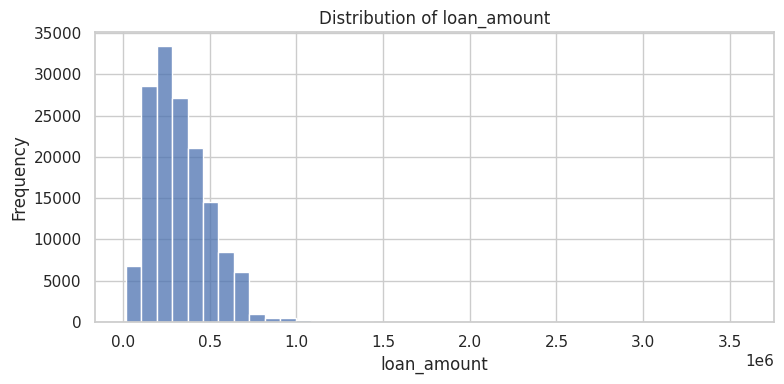

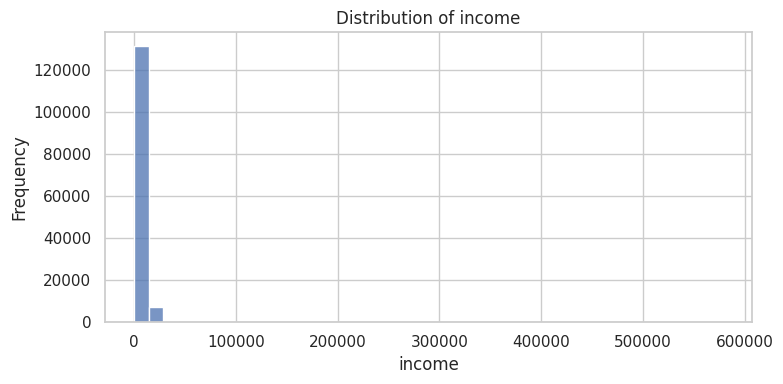

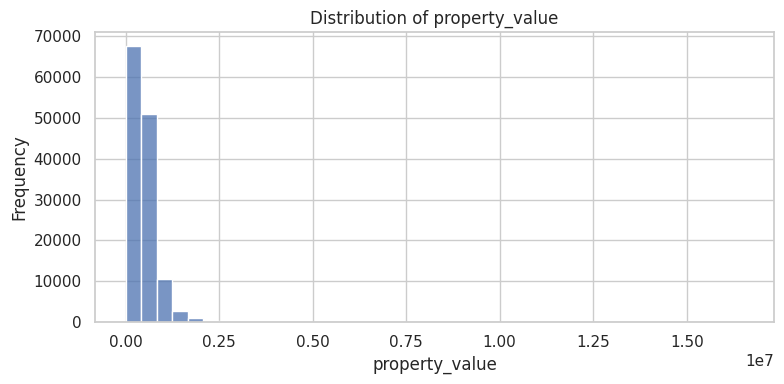

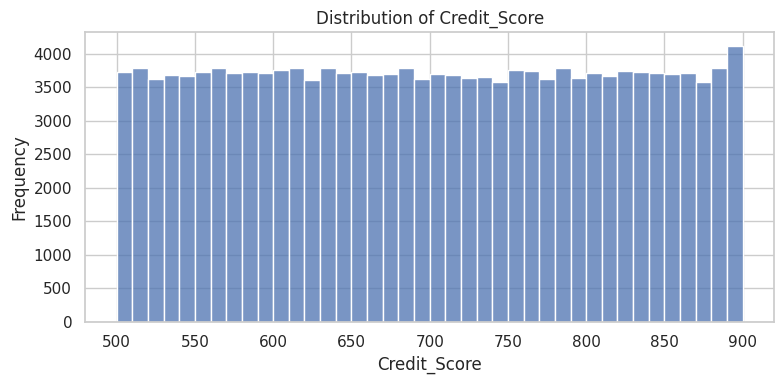

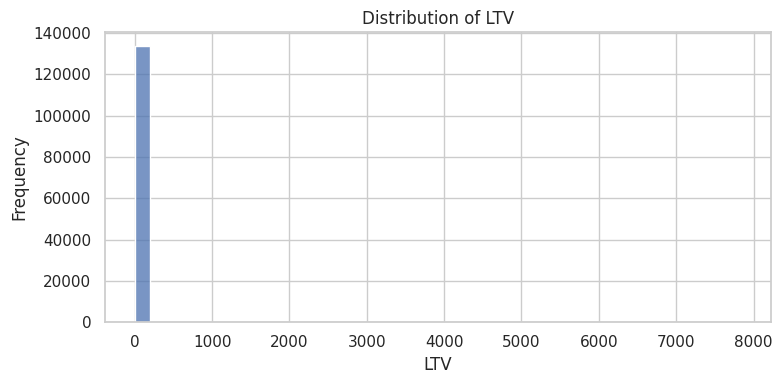

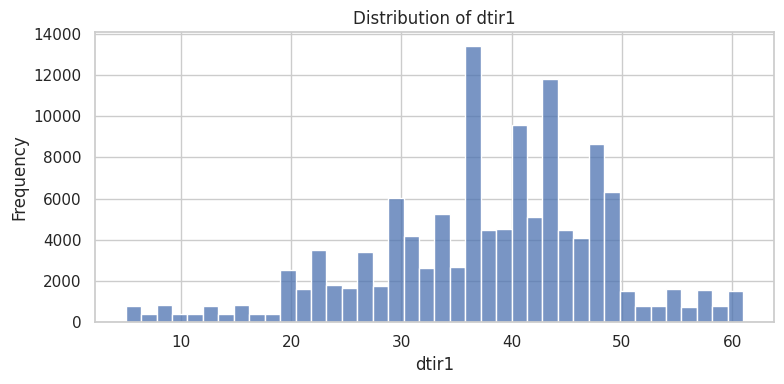

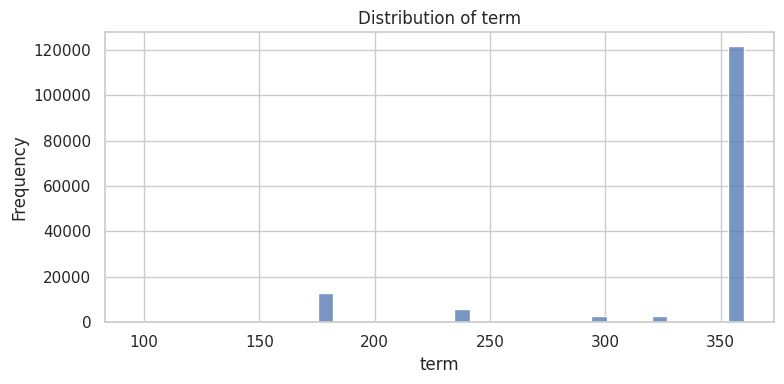

In [320]:
# 11. DISTRIBUTION ANALYSIS OF KEY NUMERICAL FEATURES
# Histograms help identify skewness, concentration, extreme values and unusual shapes.
key_numeric_features = [
 "loan_amount", "income", "property_value",
 "Credit_Score", "LTV", "dtir1", "term"
]
for column in key_numeric_features:
 if column not in df.columns:
      continue
 plt.figure(figsize=(8, 4))
 sns.histplot(data=df, x=column, bins=40, kde=False)
 plt.title(f"Distribution of {column}")
 plt.xlabel(column)
 plt.ylabel("Frequency")
 plt.tight_layout()
 plt.show()


In [321]:
# 12. IMPORTANT NUMERICAL RANGES
range_results = []
for column in key_numeric_features:
 if column not in df.columns:
     continue
 range_results.append({
 "Feature": column,
 "Minimum": df[column].min(),
 "Maximum": df[column].max(),
 "Mean": df[column].mean(),
 "Median": df[column].median(),
 "Missing_Count": df[column].isna().sum()
 })
range_table = pd.DataFrame(range_results)
display(range_table.round(2))


,Feature,Minimum,Maximum,Mean,Median,Missing_Count
0,loan_amount,16500.00,3576500.00,331117.74,296500.00,0
1,income,0.00,578580.00,6957.34,5760.00,9150
2,property_value,8000.00,16508000.00,497893.47,418000.00,15098
3,Credit_Score,500.00,900.00,699.79,699.00,0
4,LTV,0.97,7831.25,72.75,75.14,15098
5,dtir1,5.00,61.00,37.73,39.00,24121
6,term,96.00,360.00,335.14,360.00,41


# Member 2 - Praneesha
# Stage 3: Target, Class Imbalance, Missing Values and Duplicates

In [322]:
# 1. TARGET VALUES
# 1. TARGET VALUES
TARGET = "Status"
print("Unique target values:", sorted(df[TARGET].dropna().unique()))
print("Unique target values:", sorted(df[TARGET].dropna().unique()))

Unique target values: [np.int64(0), np.int64(1)]
Unique target values: [np.int64(0), np.int64(1)]


In [323]:
# 2. TARGET CLASS COUNTS
target_counts = df[TARGET].value_counts().sort_index()
print(target_counts)

Status
0    112031
1     36639
Name: count, dtype: int64


In [324]:
# 3. TARGET CLASS PERCENTAGES
target_percentages = (
 df[TARGET].value_counts(normalize=True).sort_index() * 100
)
print(target_percentages.round(2))

Status
0    75.36
1    24.64
Name: proportion, dtype: float64


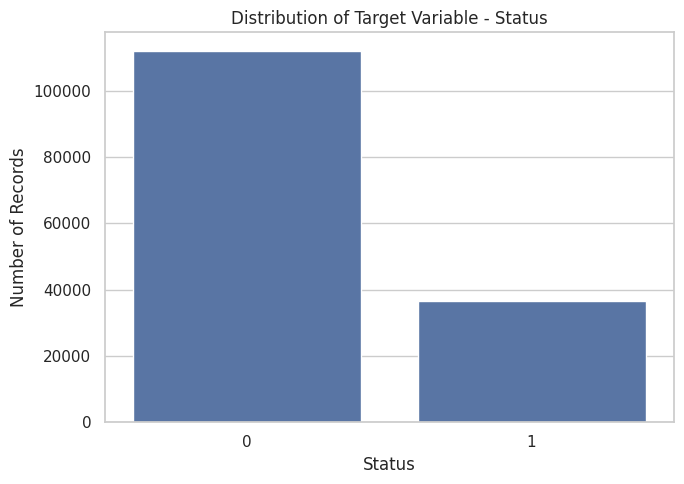

In [325]:
# 4. TARGET CLASS DISTRIBUTION GRAPH
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=TARGET)
plt.title("Distribution of Target Variable - Status")
plt.xlabel("Status")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

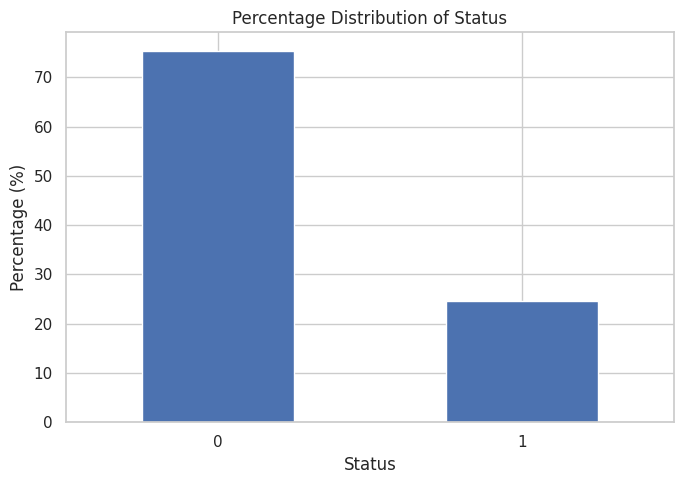

In [326]:
# 5. TARGET PERCENTAGE GRAPH
plt.figure(figsize=(7, 5))
target_percentages.plot(kind="bar")
plt.title("Percentage Distribution of Status")
plt.xlabel("Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [327]:
# 6. MISSING VALUE ANALYSIS
missing_count = df.isna().sum()
missing_percentage = df.isna().mean() * 100
missing_summary = pd.DataFrame({
 "Missing_Count": missing_count,
 "Missing_Percentage": missing_percentage
})
missing_summary = (
 missing_summary[missing_summary["Missing_Count"] > 0]
 .sort_values("Missing_Percentage", ascending=False)
)
display(missing_summary.round(2))

,Missing_Count,Missing_Percentage
Upfront_charges,39642,26.66
Interest_rate_spread,36639,24.64
rate_of_interest,36439,24.51
dtir1,24121,16.22
property_value,15098,10.16
LTV,15098,10.16
income,9150,6.15
loan_limit,3344,2.25
approv_in_adv,908,0.61
submission_of_application,200,0.13


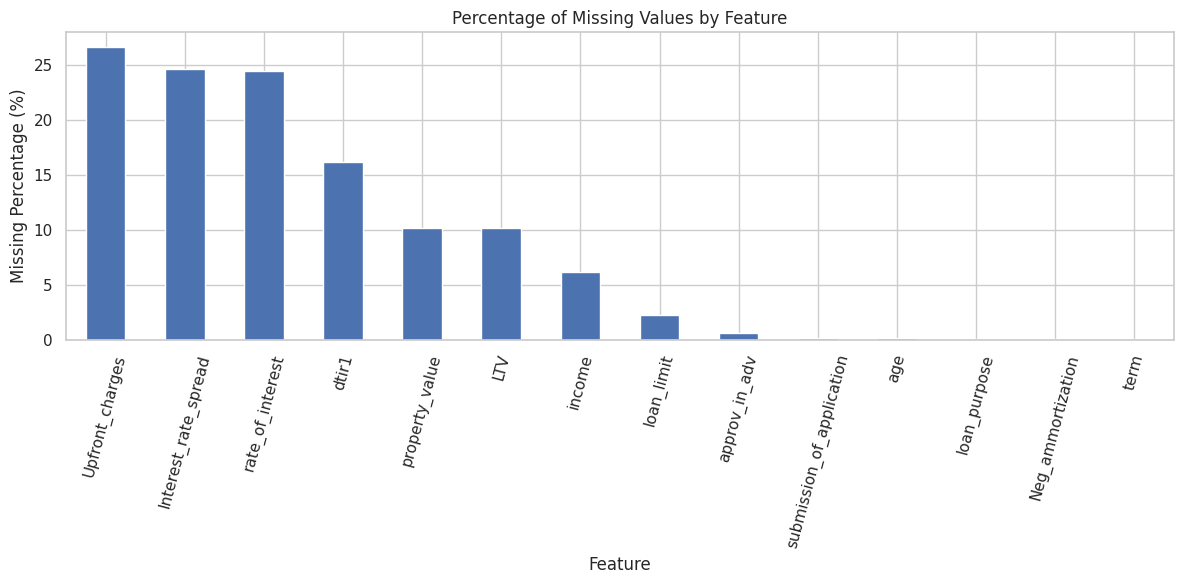

In [328]:
# 7. MISSING VALUE GRAPH
if len(missing_summary) > 0:
 plt.figure(figsize=(12, 6))
 missing_summary["Missing_Percentage"].plot(kind="bar")
 plt.title("Percentage of Missing Values by Feature")
 plt.xlabel("Feature")
 plt.ylabel("Missing Percentage (%)")
 plt.xticks(rotation=75)
 plt.tight_layout()
 plt.show()

In [329]:
# 8. EXACT DUPLICATES
duplicate_rows = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_rows)

Number of exact duplicate rows: 0


In [330]:
# 9. ID UNIQUENESS
# Confirms whether ID functions as a unique row identifier.
if "ID" in df.columns:
 print("Number of rows :", len(df))
 print("Number of unique IDs :", df["ID"].nunique())
 print("Duplicated ID values :", df["ID"].duplicated().sum())

Number of rows : 148670
Number of unique IDs : 148670
Duplicated ID values : 0


# MEMBER 3 - DILKI - STAGE 3
# CORRELATION, NUMERICAL FEATURE-TARGET RELATIONSHIPS AND OUTLIERS

In [331]:
# 1. CORRELATION MATRIX
correlation_features = (
 df.select_dtypes(include=["number"])
 .columns
 .tolist()
)
# ID is numeric in storage but is an identifier, so exclude it from correlation analysis.
if "ID" in correlation_features:
  correlation_features.remove("ID")
    
correlation_matrix = df[correlation_features].corr()
display(correlation_matrix.round(2))

,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,NaN,1.00,-0.15,-0.38,0.07,0.17,0.73,0.46,0.00,0.04,-0.04,0.02
rate_of_interest,NaN,-0.15,1.00,0.61,-0.08,0.21,-0.12,-0.04,-0.00,-0.00,0.02,0.06
Interest_rate_spread,NaN,-0.38,0.61,1.00,0.03,-0.16,-0.33,-0.15,-0.00,0.04,NaN,0.08
Upfront_charges,NaN,0.07,-0.08,0.03,1.00,-0.05,0.05,0.02,-0.00,-0.03,-0.02,0.00
term,NaN,0.17,0.21,-0.16,-0.05,1.00,0.05,-0.05,-0.00,0.11,-0.00,0.11
property_value,NaN,0.73,-0.12,-0.33,0.05,0.05,1.00,0.41,0.00,-0.22,-0.05,-0.06
income,NaN,0.46,-0.04,-0.15,0.02,-0.05,0.41,1.00,0.00,-0.07,-0.07,-0.27
Credit_Score,NaN,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,1.00,-0.01,0.00,-0.00
LTV,NaN,0.04,-0.00,0.04,-0.03,0.11,-0.22,-0.07,-0.01,1.00,0.04,0.16


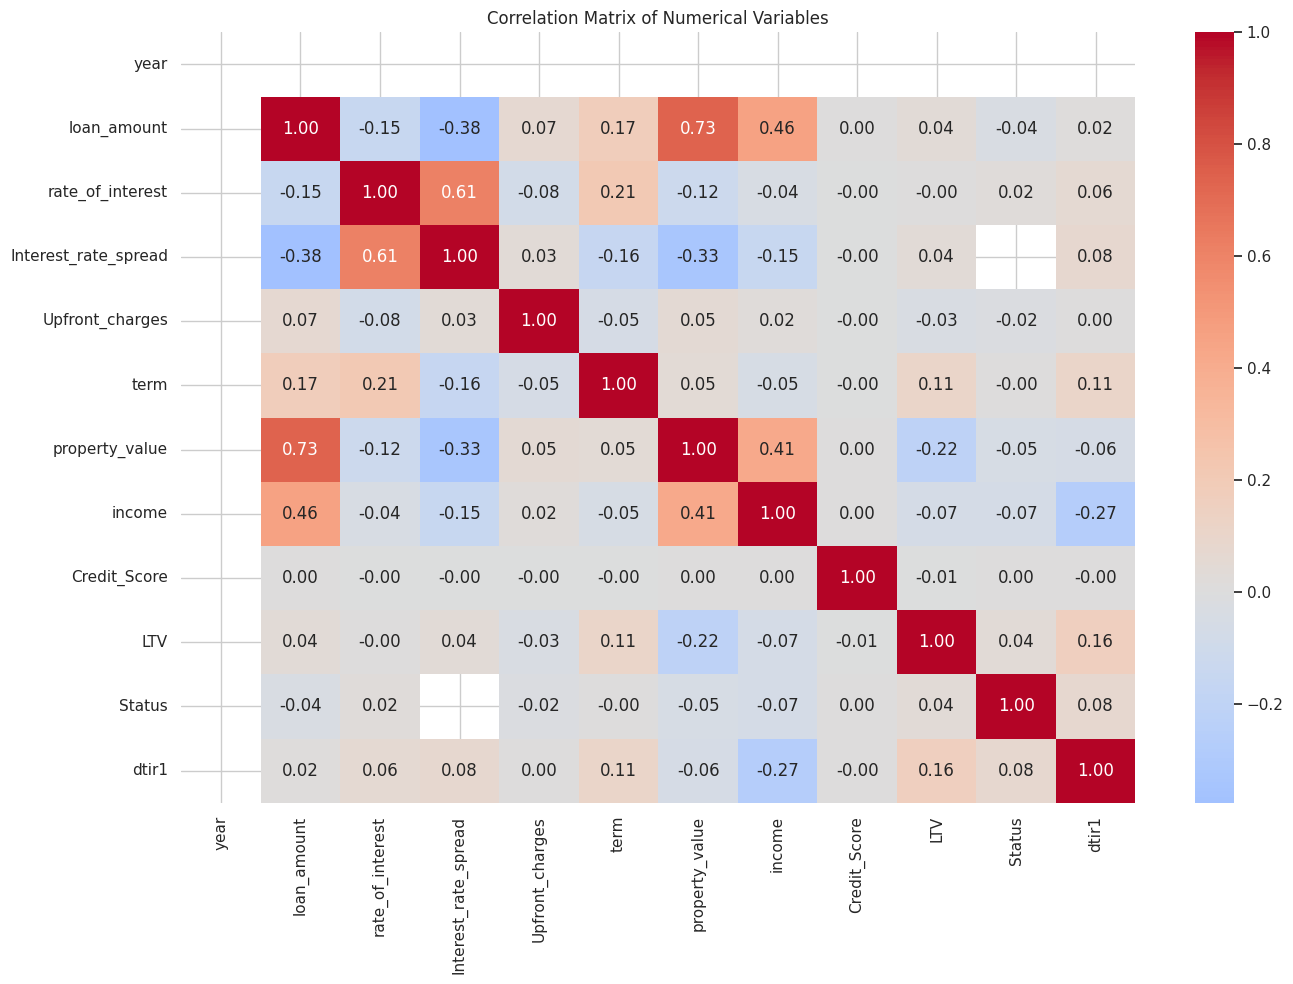

In [332]:
# 2. CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
sns.heatmap(
 correlation_matrix,
 annot=True,
 fmt=".2f",
 cmap="coolwarm",
 center=0
)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


In [333]:
# 3. CORRELATION WITH STATUS
# Sort by absolute correlation only as an exploratory indicator.
if TARGET in correlation_matrix.columns:
 status_correlations = (
 correlation_matrix[TARGET]
 .drop(TARGET)
 .sort_values(key=abs, ascending=False)
 )
 display(status_correlations.to_frame("Correlation_with_Status"))

,Correlation_with_Status
dtir1,0.078083
income,-0.065119
property_value,-0.048864
LTV,0.038895
loan_amount,-0.036825
rate_of_interest,0.022957
Upfront_charges,-0.019138
Credit_Score,0.004004
term,-0.000240
year,NaN


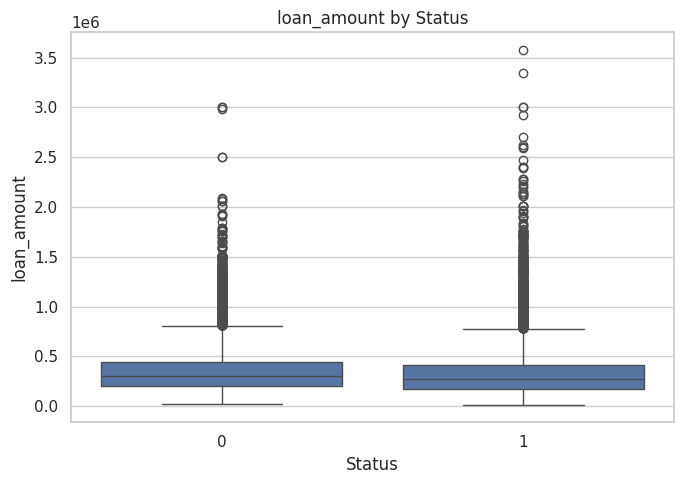

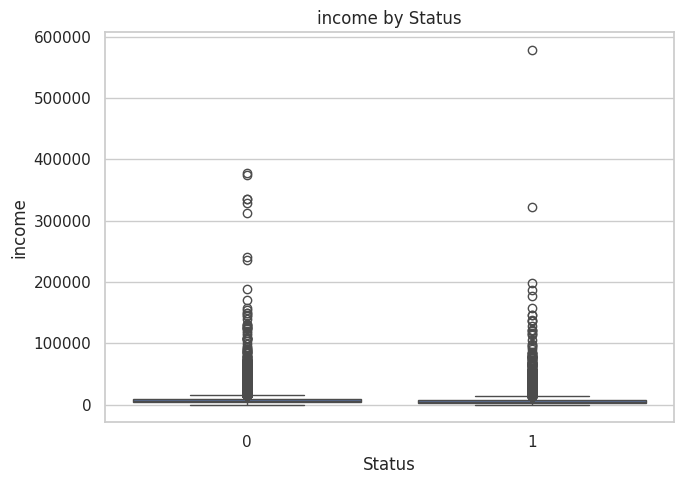

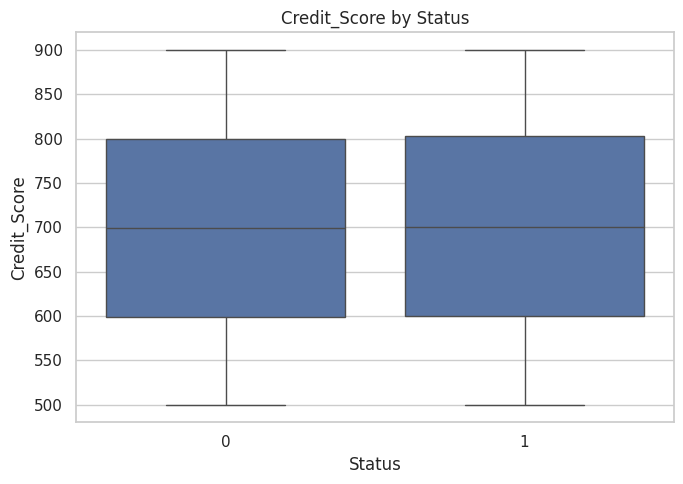

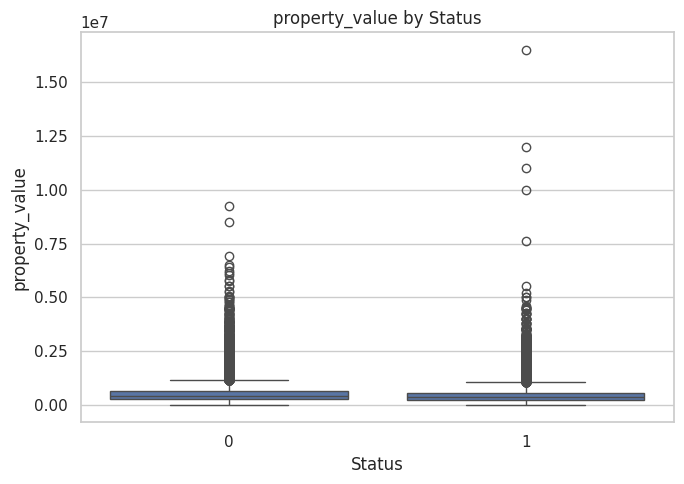

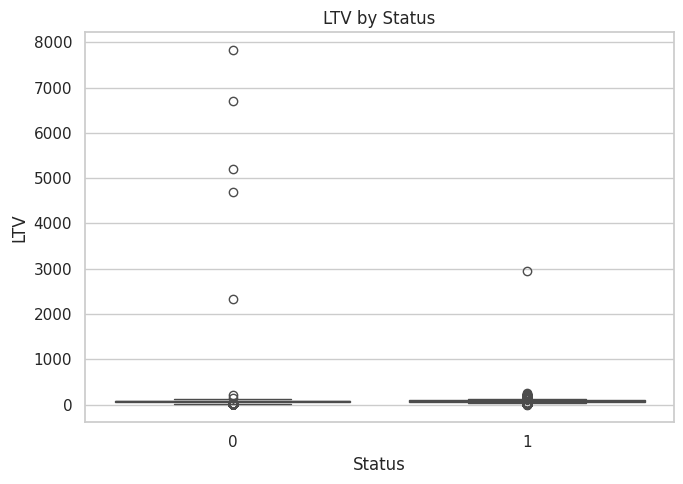

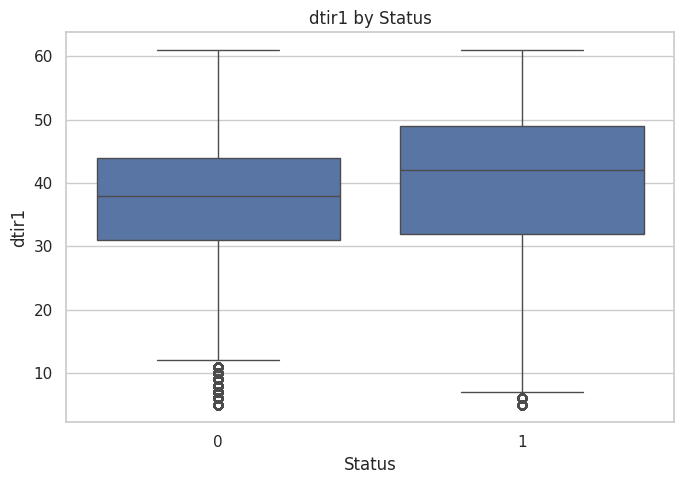

In [334]:
# 4. NUMERICAL FEATURES VS TARGET
numerical_target_features = [
 "loan_amount", "income", "Credit_Score",
 "property_value", "LTV", "dtir1"
]
for column in numerical_target_features:
 if column not in df.columns:
     continue
 plt.figure(figsize=(7, 5))
 sns.boxplot(data=df, x=TARGET, y=column)
 plt.title(f"{column} by Status")
 plt.xlabel("Status")
 plt.ylabel(column)
 plt.tight_layout()
 plt.show()


In [335]:
# 5. IQR OUTLIER DETECTION
# Lower bound = Q1 - 1.5*IQR
# Upper bound = Q3 + 1.5*IQR
# Flagged values are potential statistical outliers, NOT automatically invalid rows.
outlier_columns = [
 c for c in df.select_dtypes(include=["number"]).columns
 if c not in ["ID", TARGET, "year"]
]
outlier_results = []
for column in outlier_columns:
 values = df[column].dropna()
 if len(values) == 0:
     continue
 Q1 = values.quantile(0.25)
 Q3 = values.quantile(0.75)
 IQR = Q3 - Q1
 lower_bound = Q1 - 1.5 * IQR
 upper_bound = Q3 + 1.5 * IQR
 outlier_mask = (values < lower_bound) | (values > upper_bound)
 outlier_count = outlier_mask.sum()
 outlier_results.append({
     "Feature": column,
     "Q1": Q1,
     "Q3": Q3,
     "IQR": IQR,
     "Lower_Bound": lower_bound,
     "Upper_Bound": upper_bound,
     "Outlier_Count": outlier_count,
     "Outlier_Percentage": outlier_count / len(values) * 100
 })
outlier_summary = (
 pd.DataFrame(outlier_results)
 .sort_values("Outlier_Percentage", ascending=False)
)
display(outlier_summary.round(2))

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
4,term,360.00,360.00,0.00,360.00,360.00,26944,18.13
6,income,3720.00,8520.00,4800.00,-3480.00,15720.00,6546,4.69
5,property_value,268000.00,628000.00,360000.00,-272000.00,1168000.00,5266,3.94
3,Upfront_charges,581.49,4812.50,4231.01,-5765.02,11159.02,2880,2.64
9,dtir1,31.00,45.00,14.00,10.00,66.00,2013,1.62
8,LTV,60.47,86.18,25.71,21.91,124.75,1882,1.41
0,loan_amount,196500.00,436500.00,240000.00,-163500.00,796500.00,1895,1.27
1,rate_of_interest,3.62,4.38,0.75,2.50,5.50,856,0.76
2,Interest_rate_spread,0.08,0.78,0.70,-0.97,1.82,445,0.40
7,Credit_Score,599.00,800.00,201.00,297.50,1101.50,0,0.00


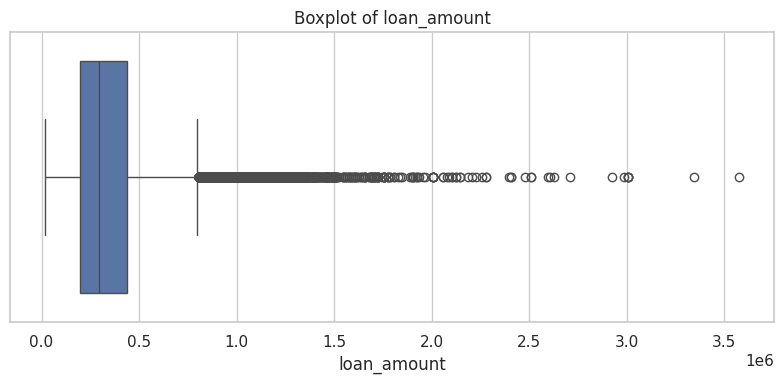

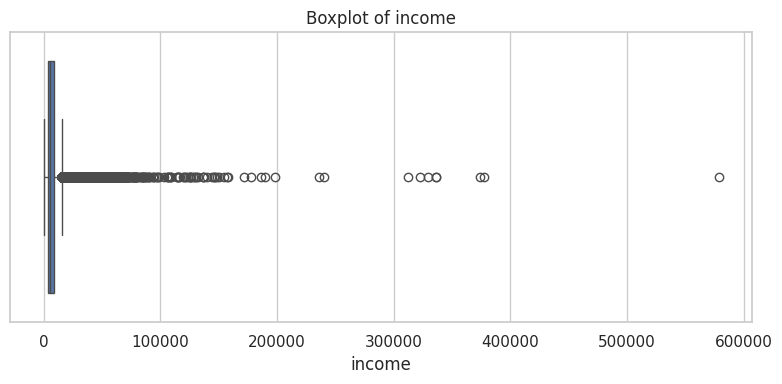

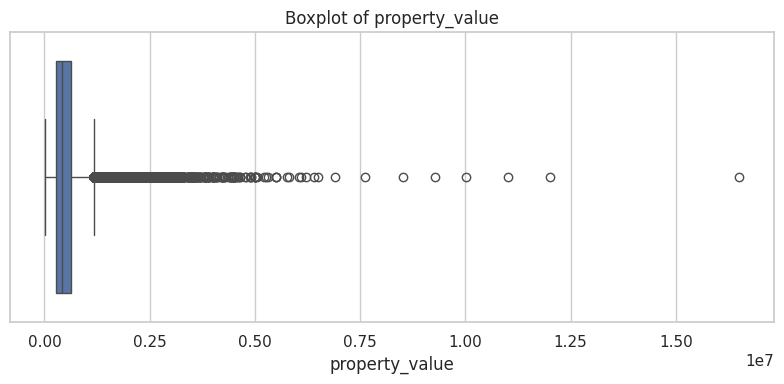

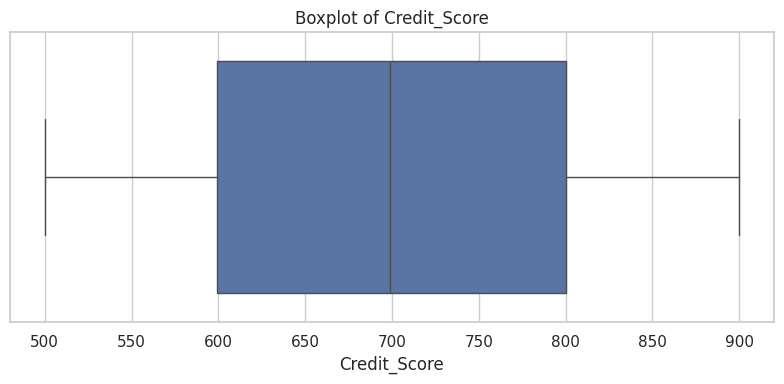

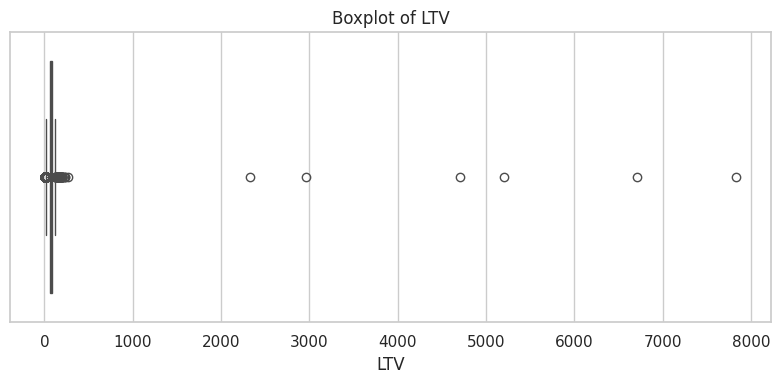

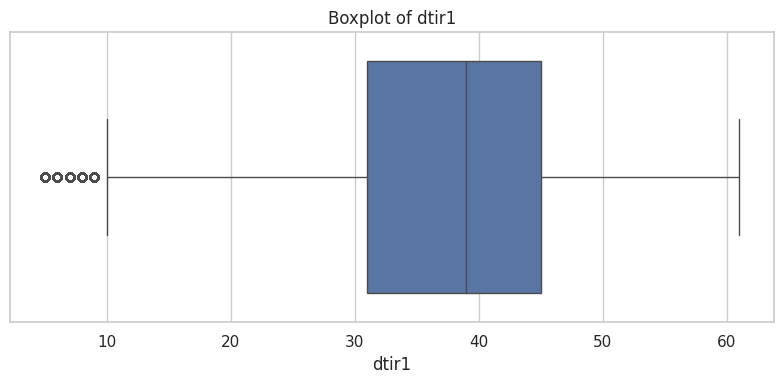

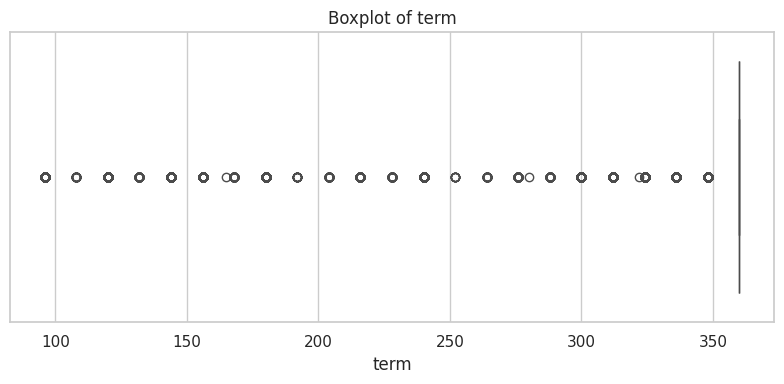

In [336]:
# 6. BOXPLOTS FOR IMPORTANT FEATURES
key_numeric_features = [
 "loan_amount", "income", "property_value",
 "Credit_Score", "LTV", "dtir1", "term"
]
for column in key_numeric_features:
 if column not in df.columns:
     continue
 plt.figure(figsize=(8, 4))
 sns.boxplot(data=df, x=column)
 plt.title(f"Boxplot of {column}")
 plt.tight_layout()
 plt.show()

# MEMBER 4 - DINUJA - STAGE 3
# CATEGORICAL ANALYSIS, CATEGORICAL VS TARGET, LEAKAGE INVESTIGATION

In [337]:
# 1. CATEGORICAL VALUE COUNTS
categorical_columns = (
 df.select_dtypes(include=["object", "category"])
 .columns
 .tolist()
)
for column in categorical_columns:
 print("\n" + "=" * 70)
 print("COLUMN:", column)
 print("=" * 70)
 print(df[column].value_counts(dropna=False))



COLUMN: loan_limit
loan_limit
cf     135348
ncf      9978
NaN      3344
Name: count, dtype: int64

COLUMN: Gender
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64

COLUMN: approv_in_adv
approv_in_adv
nopre    124621
pre       23141
NaN         908
Name: count, dtype: int64

COLUMN: loan_type
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

COLUMN: loan_purpose
loan_purpose
p3     55934
p4     54799
p1     34529
p2      3274
NaN      134
Name: count, dtype: int64

COLUMN: Credit_Worthiness
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64

COLUMN: open_credit
open_credit
nopc    148114
opc        556
Name: count, dtype: int64

COLUMN: business_or_commercial
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64

COLUMN: Neg_ammortization
Neg_ammortization
not_neg    133420
neg_amm     15129
NaN           121
Name: 

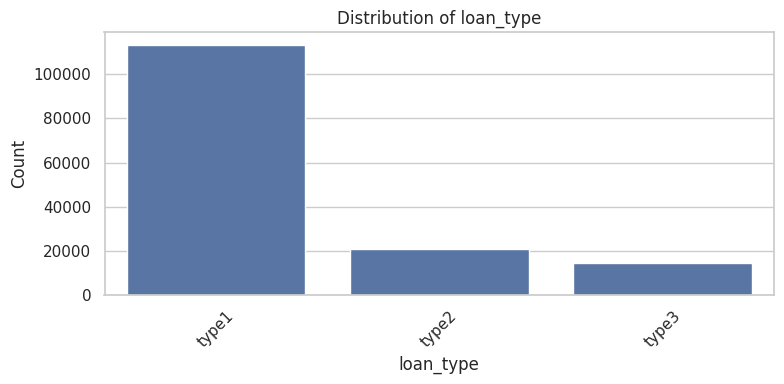

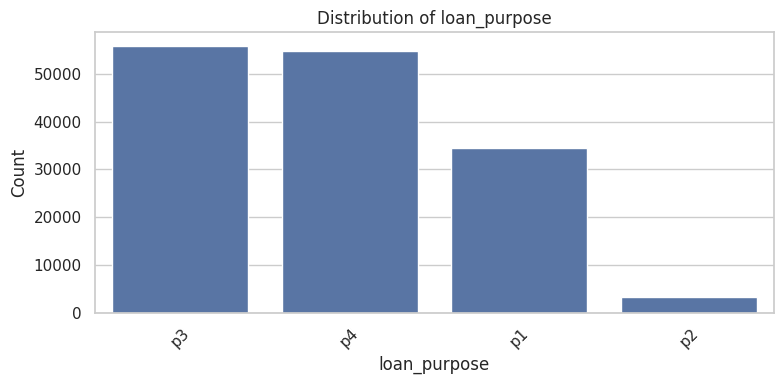

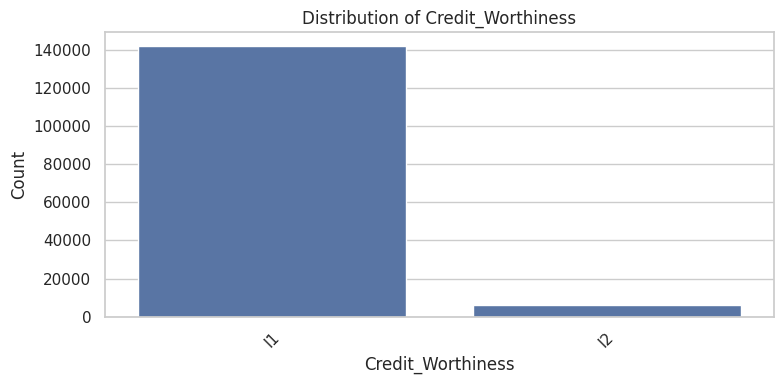

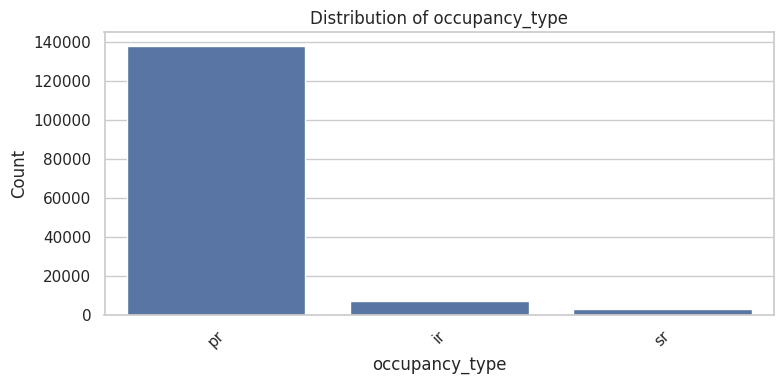

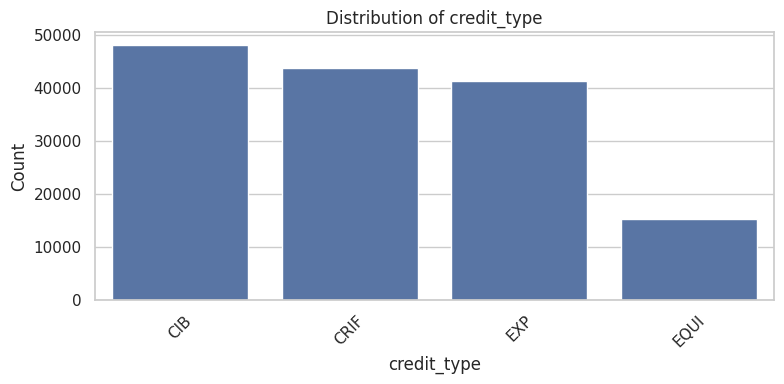

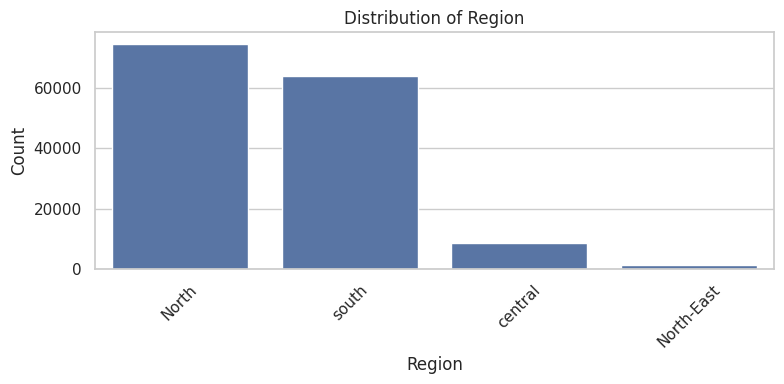

In [338]:
# 2. SELECTED CATEGORICAL DISTRIBUTION GRAPHS
selected_categorical_features = [
 "loan_type", "loan_purpose", "Credit_Worthiness",
 "occupancy_type", "credit_type", "Region"
]
for column in selected_categorical_features:
 if column not in df.columns:
     continue
 plt.figure(figsize=(8, 4))
 sns.countplot(
 data=df,
 x=column,
 order=df[column].value_counts().index
 )
 plt.title(f"Distribution of {column}")
 plt.xlabel(column)
 plt.ylabel("Count")
 plt.xticks(rotation=45)
 plt.tight_layout()
 plt.show()


Status distribution by loan_type


Status,0,1
loan_type,,
type1,77.23,22.77
type2,65.46,34.54
type3,74.94,25.06


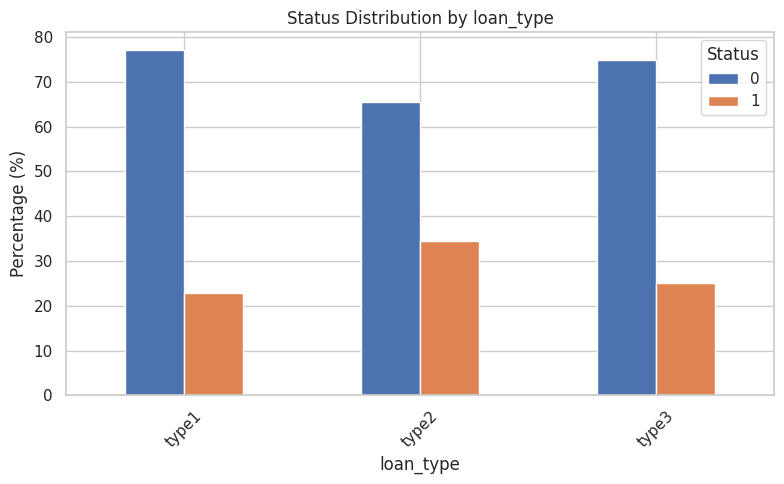


Status distribution by loan_purpose


Status,0,1
loan_purpose,,
p1,74.12,25.88
p2,66.92,33.08
p3,74.98,25.02
p4,77.03,22.97


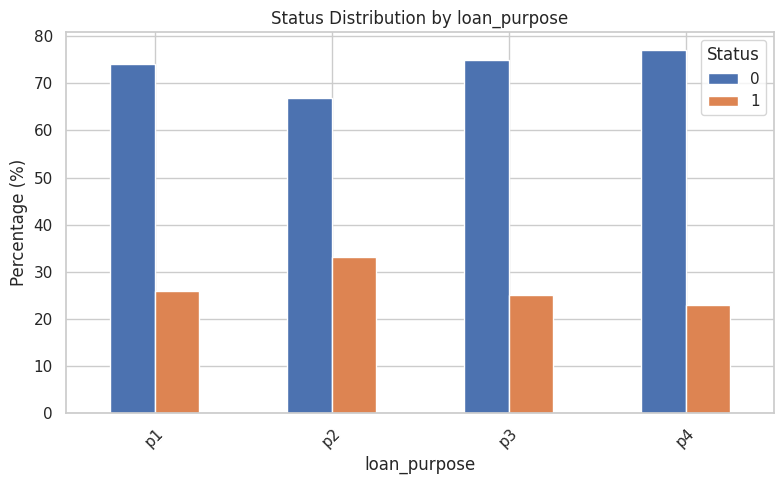


Status distribution by Credit_Worthiness


Status,0,1
Credit_Worthiness,,
l1,75.67,24.33
l2,68.23,31.77


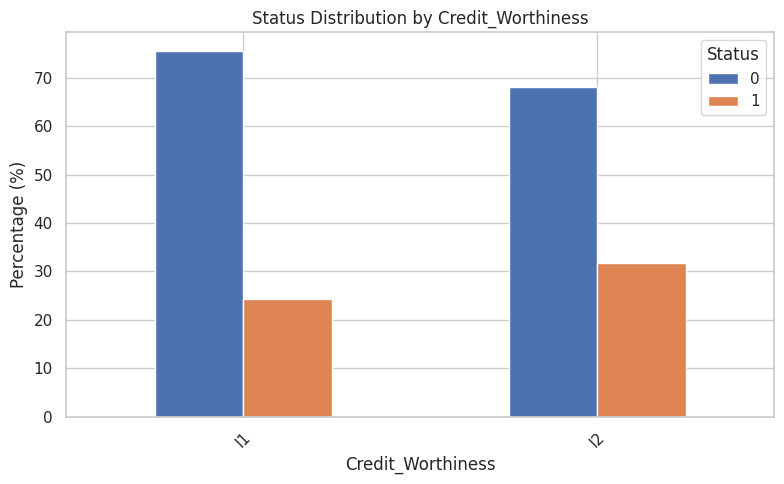


Status distribution by occupancy_type


Status,0,1
occupancy_type,,
ir,70.01,29.99
pr,75.70,24.30
sr,72.87,27.13


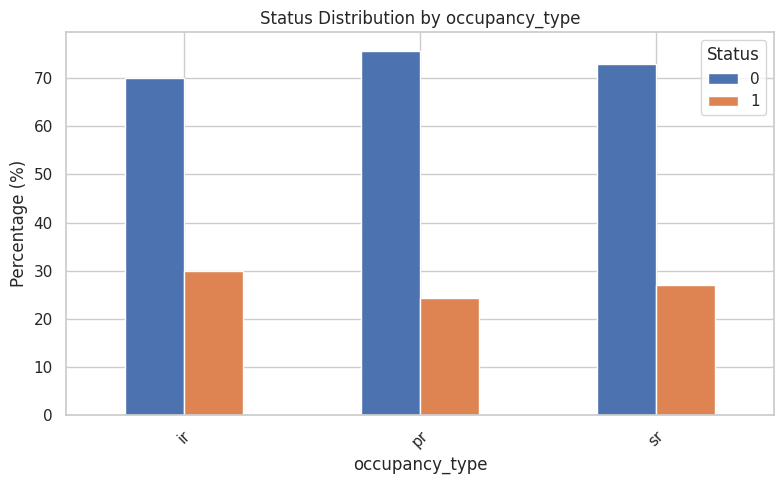


Status distribution by credit_type


Status,0,1
credit_type,,
CIB,84.20,15.80
CRIF,83.77,16.23
EQUI,0.01,99.99
EXP,84.01,15.99


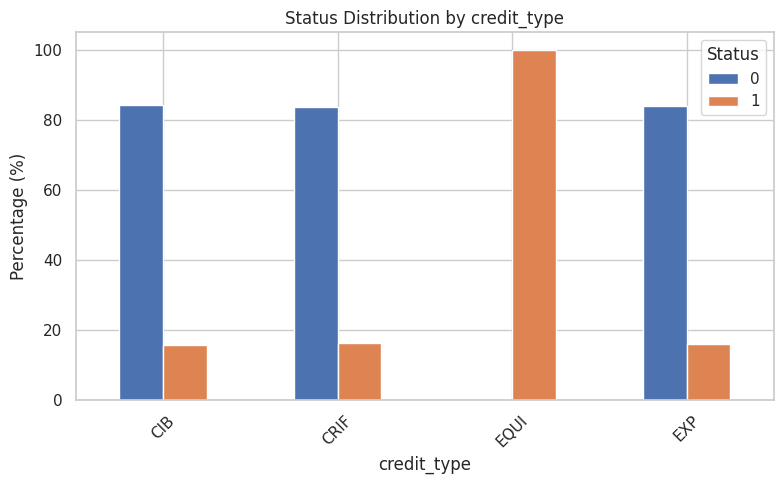


Status distribution by Region


Status,0,1
Region,,
North,77.49,22.51
North-East,69.55,30.45
central,72.46,27.54
south,73.37,26.63


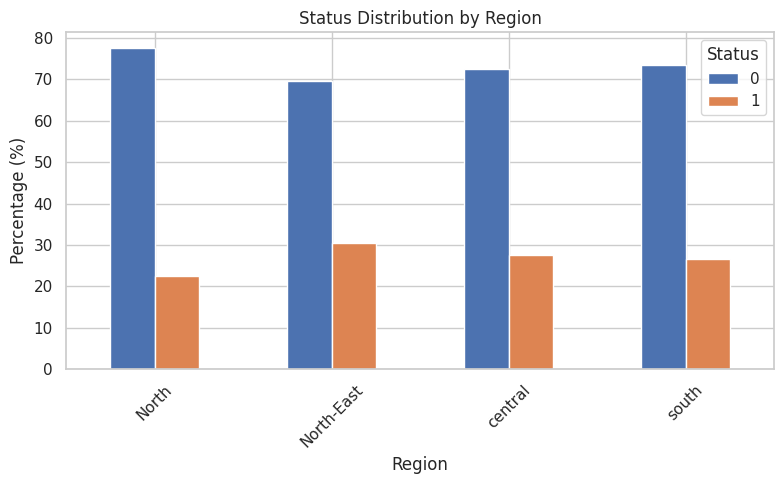

In [339]:
# 3. CATEGORICAL FEATURE VS STATUS
# Crosstab percentages compare target distribution within each category.
for column in selected_categorical_features:
 if column not in df.columns:
     continue
 table = pd.crosstab(
 df[column],
 df[TARGET],
 normalize="index"
 ) * 100
 print("\nStatus distribution by", column)
 display(table.round(2))
 table.plot(kind="bar", figsize=(8, 5))
 plt.title(f"Status Distribution by {column}")
 plt.xlabel(column)
 plt.ylabel("Percentage (%)")
 plt.xticks(rotation=45)
 plt.tight_layout()
 plt.show()


In [340]:
# ============================================================
# 4. LEAKAGE INVESTIGATION - MISSINGNESS BY TARGET CLASS
# ============================================================

# Missing values themselves can become predictive.
# Here we compare the percentage of missing values for each
# feature between the two target classes.

missing_by_target = []

# Go through every feature
for column in df.columns:

    # Do not analyse the target column itself
    if column == TARGET:
        continue

    # Calculate missing percentage separately for each target class
    for status_value in sorted(df[TARGET].dropna().unique()):

        subset = df[df[TARGET] == status_value]

        missing_pct = subset[column].isna().mean() * 100

        missing_by_target.append({
            "Feature": column,
            "Status": status_value,
            "Missing_Percentage": missing_pct
        })


# Convert results into a DataFrame
missing_by_target_df = pd.DataFrame(missing_by_target)


# Create pivot table:
# rows    = features
# columns = target classes
# values  = missing percentages
missing_pivot = missing_by_target_df.pivot(
    index="Feature",
    columns="Status",
    values="Missing_Percentage"
)


# ------------------------------------------------------------
# Automatically identify the two target classes
# ------------------------------------------------------------

target_classes = list(missing_pivot.columns)

print("Target classes found:", target_classes)


if len(target_classes) == 2:

    class_1 = target_classes[0]
    class_2 = target_classes[1]

    # Calculate how different the missingness is
    # between the two target classes
    missing_pivot["Absolute_Difference"] = abs(
        missing_pivot[class_1] - missing_pivot[class_2]
    )

    # Sort features from highest difference to lowest
    missing_pivot = missing_pivot.sort_values(
        "Absolute_Difference",
        ascending=False
    )

    # Display the top 15
    display(missing_pivot.head(15).round(2))

else:
    print(
        "Expected exactly 2 target classes, but found:",
        target_classes
    )

Target classes found: [0, 1]


Status,0,1,Absolute_Difference
Feature,,,
Interest_rate_spread,0.00,100.00,100.00
rate_of_interest,0.00,99.45,99.45
Upfront_charges,2.82,99.58,96.77
property_value,0.00,41.20,41.20
LTV,0.00,41.20,41.20
dtir1,6.97,44.52,37.54
income,7.06,3.38,3.68
submission_of_application,0.00,0.55,0.55
age,0.00,0.55,0.55


In [341]:
# 5. SPECIFICALLY INSPECT SUSPICIOUS FEATURES
# Strong association does NOT prove leakage by itself.
# Verify when each variable becomes available in the real loan process.
suspicious_features = [
 "Interest_rate_spread",
 "rate_of_interest",
 "Upfront_charges"
]
for column in suspicious_features:
 if column not in df.columns:
     continue
 result = (
 df.groupby(TARGET)[column]
 .apply(lambda values: values.isna().mean() * 100)
 )
 print("\nFeature:", column)
 print(result.round(2))



Feature: Interest_rate_spread
Status
0      0.0
1    100.0
Name: Interest_rate_spread, dtype: float64

Feature: rate_of_interest
Status
0     0.00
1    99.45
Name: rate_of_interest, dtype: float64

Feature: Upfront_charges
Status
0     2.82
1    99.58
Name: Upfront_charges, dtype: float64


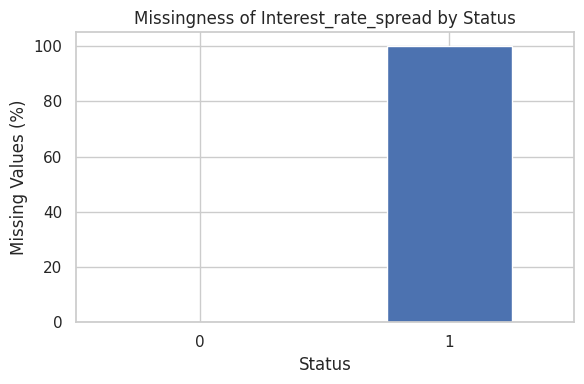

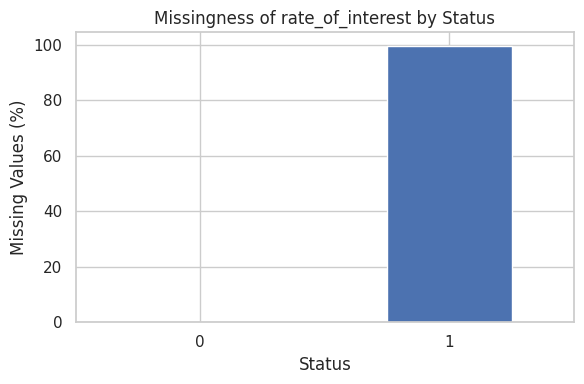

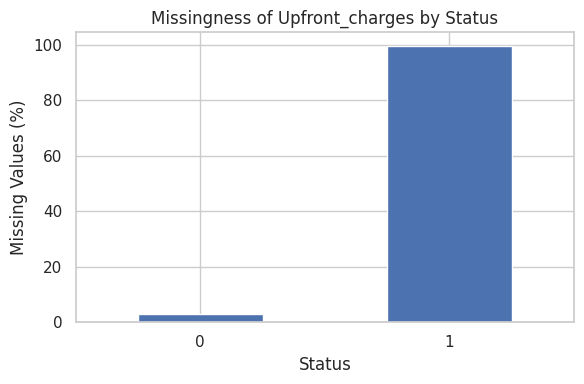

In [342]:
# 6. VISUALISE SUSPICIOUS MISSINGNESS
for column in suspicious_features:
 if column not in df.columns:
     continue
 temp = df[[TARGET, column]].copy()
 temp["Missing"] = temp[column].isna().astype(int)
 missing_rate = temp.groupby(TARGET)["Missing"].mean() * 100
 plt.figure(figsize=(6, 4))
 missing_rate.plot(kind="bar")
 plt.title(f"Missingness of {column} by Status")
 plt.xlabel("Status")
 plt.ylabel("Missing Values (%)")
 plt.xticks(rotation=0)
 plt.tight_layout()
 plt.show()


# Stage 4

## MEMBER 1 - SHANAKA - STAGE 4
## DATA CLEANING, INVALID RECORDS, ID/CONSTANT REMOVAL, OUTLIER DECISIONS

In [343]:
# 1. CREATE A WORKING COPY
# Keep raw df unchanged in case we need to revise a preprocessing decision.
stage4_df = df.copy()
print("Original Stage 4 shape:", stage4_df.shape)

Original Stage 4 shape: (148670, 34)


In [344]:
# 2. CLEAN CATEGORICAL WHITESPACE
# Example: "North" and "North " should not become separate categories.
object_columns_stage4 = stage4_df.select_dtypes(include=["object"]).columns
for column in object_columns_stage4:
 stage4_df[column] = stage4_df[column].apply(
 lambda x: x.strip() if isinstance(x, str) else x
 )
# Convert completely blank strings into proper missing values.
stage4_df.replace(r"^\s*$", np.nan, regex=True, inplace=True)

In [345]:
# 3. REMOVE EXACT DUPLICATES IF PRESENT
rows_before = stage4_df.shape[0]
stage4_df = stage4_df.drop_duplicates().copy()
rows_after = stage4_df.shape[0]
print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal :", rows_after)
print("Duplicates removed :", rows_before - rows_after)

Rows before duplicate removal: 148670
Rows after duplicate removal : 148670
Duplicates removed : 0


In [346]:
# 4. CHECK OBVIOUS NEGATIVE VALUES
# Report suspicious negatives first; do not blindly remove them without domain validation.
non_negative_features = [
 "loan_amount", "income", "property_value",
 "Credit_Score", "LTV", "dtir1", "term"
]
invalid_results = []
for column in non_negative_features:
 if column not in stage4_df.columns:
     continue
 invalid_results.append({
 "Feature": column,
 "Negative_Value_Count": stage4_df[column].dropna().lt(0).sum()
 })
invalid_summary = pd.DataFrame(invalid_results)
display(invalid_summary)

,Feature,Negative_Value_Count
0,loan_amount,0
1,income,0
2,property_value,0
3,Credit_Score,0
4,LTV,0
5,dtir1,0
6,term,0


In [347]:
# 5. REMOVE ID
# ID is a record identifier, not normally a meaningful borrower-risk feature.
if "ID" in stage4_df.columns:
 stage4_df.drop(columns=["ID"], inplace=True)
 print("ID removed.")

ID removed.


In [348]:
# 6. REMOVE CONSTANT FEATURES
constant_stage4 = [
 c for c in stage4_df.columns
 if stage4_df[c].nunique(dropna=False) == 1
]
print("Constant features removed:", constant_stage4)
stage4_df.drop(columns=constant_stage4, inplace=True)

Constant features removed: ['year']


In [349]:
# 7. OUTLIER DECISION
# IQR can identify statistical outliers, but a statistical outlier is not automatically invalid.
# High income, property value or loan amount can be legitimate financial observations.
print("""
OUTLIER TREATMENT DECISION
- Potential outliers were identified using IQR during Stage 3.
- They are NOT automatically removed.
- Extreme financial values may be genuine customers.
- Removal/treatment should only be justified when values are erroneous or unsuitable for
 a specific model.
""")


OUTLIER TREATMENT DECISION
- Potential outliers were identified using IQR during Stage 3.
- They are NOT automatically removed.
- Extreme financial values may be genuine customers.
- Removal/treatment should only be justified when values are erroneous or unsuitable for
 a specific model.



# MEMBER 4 - DINUJA - STAGE 4 PART A
# LEAKAGE PREVENTION, X/y SEPARATION AND STRATIFIED TRAIN/TEST SPLIT
# RUN AFTER SHANAKA CREATES stage4_df


In [350]:
# 1. POTENTIAL LEAKAGE FEATURES
# EDA showed extremely target-associated missingness for these variables.
# Association alone does not prove leakage, but a conservative pipeline excludes them
# until their real-world availability is verified.
potential_leakage_features = [
 "Interest_rate_spread",
 "rate_of_interest",
 "Upfront_charges"
]
existing_potential_leakage_features = [
 c for c in potential_leakage_features
 if c in stage4_df.columns
]
print("Potential leakage features excluded:")
print(existing_potential_leakage_features)
stage4_safe_df = stage4_df.drop(
 columns=existing_potential_leakage_features
).copy()
print("Shape after conservative leakage removal:", stage4_safe_df.shape)

Potential leakage features excluded:
['Interest_rate_spread', 'rate_of_interest', 'Upfront_charges']
Shape after conservative leakage removal: (148670, 29)


In [351]:
# 2. SEPARATE X AND y
X = stage4_safe_df.drop(columns=[TARGET])
y = stage4_safe_df[TARGET]
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (148670, 28)
y shape: (148670,)


In [352]:
# 3. STRATIFIED TRAIN/TEST SPLIT
# 80% training, 20% testing.
# stratify=y preserves approximately the same target-class proportions.
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.20,
 random_state=42,
 stratify=y
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (118936, 28)
X_test : (29734, 28)
y_train: (118936,)
y_test : (29734,)


In [353]:
# 4. VERIFY STRATIFICATION
print("\nOriginal target distribution (%):")
print(y.value_counts(normalize=True).sort_index().mul(100).round(2))
print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).sort_index().mul(100).round(2))
print("\nTesting target distribution (%):")
print(y_test.value_counts(normalize=True).sort_index().mul(100).round(2))



Original target distribution (%):
Status
0    75.36
1    24.64
Name: proportion, dtype: float64

Training target distribution (%):
Status
0    75.36
1    24.64
Name: proportion, dtype: float64

Testing target distribution (%):
Status
0    75.35
1    24.65
Name: proportion, dtype: float64


# MEMBER 2 - PRANEESHA - STAGE 4
# MISSING VALUE HANDLING AND IMPUTATION
# RUN AFTER DINUJA CREATES X_train / X_test

In [354]:
# 1. IDENTIFY FEATURE TYPES FROM TRAINING DATA
numeric_features = (
 X_train.select_dtypes(include=["number"])
 .columns
 .tolist()
)
categorical_features = (
 X_train.select_dtypes(include=["object", "category"])
 .columns
 .tolist()
)
print("Numerical features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)


Numerical features:
['loan_amount', 'term', 'property_value', 'income', 'Credit_Score', 'LTV', 'dtir1']

Categorical features:
['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']


In [355]:
# 2. COMPARE MEAN AND MEDIAN
# Large mean/median differences can indicate skewness or influence from extreme values.
if len(numeric_features) > 0:
 mean_median_table = pd.DataFrame({
 "Mean": X_train[numeric_features].mean(),
 "Median": X_train[numeric_features].median()
 })
 display(mean_median_table.round(2))


,Mean,Median
loan_amount,330989.56,296500.00
term,335.10,360.00
property_value,497909.29,418000.00
income,6961.14,5760.00
Credit_Score,699.82,699.00
LTV,72.75,75.12
dtir1,37.74,39.00


In [356]:
# 3. NUMERICAL IMPUTER
# Median is robust to extreme/skewed financial values.
numeric_imputer = SimpleImputer(strategy="median")


In [357]:
# 4. CATEGORICAL IMPUTER
# Use the most frequent category from TRAINING DATA.
categorical_imputer = SimpleImputer(strategy="most_frequent")


In [358]:
print("Numerical missing values -> median imputation")
print("Categorical missing values -> most-frequent imputation")
# IMPORTANT:
# Do NOT calculate medians/modes on the full dataset before splitting.
# That would allow information from the test set to influence training preprocessing.


Numerical missing values -> median imputation
Categorical missing values -> most-frequent imputation


# MEMBER 3 - DILKI - STAGE 4
# ENCODING, SCALING, FEATURE ENGINEERING AND FEATURE SELECTION

In [359]:
# 1. ONE-HOT ENCODING
# Converts unordered categorical values into binary indicator columns.
# handle_unknown="ignore" prevents failure if a new category appears in test data.
onehot_encoder = OneHotEncoder(handle_unknown="ignore")

In [360]:
# 2. STANDARD SCALING
# z = (x - mean) / standard deviation
# Useful for scale-sensitive algorithms such as Logistic Regression, KNN and SVM.
# Tree-based models generally do not require scaling.
standard_scaler = StandardScaler()

In [361]:
# 3. EXISTING DOMAIN-DERIVED FEATURES
# The dataset already contains ratio-style features such as LTV and dtir1.
print("Existing domain-derived features:")
for feature in ["LTV", "dtir1"]:
 if feature in X.columns:
    print("-", feature)


Existing domain-derived features:
- LTV
- dtir1


In [362]:
# 4. VERIFY LTV RELATIONSHIP
# LTV appears to be approximately loan_amount / property_value * 100.
required_ltv_columns = {"loan_amount", "property_value", "LTV"}
if required_ltv_columns.issubset(df.columns):
    ltv_check = (
        df[["loan_amount", "property_value", "LTV"]]
        .dropna()
        .copy()
    )
    # Avoid division by zero.
    ltv_check = ltv_check[ltv_check["property_value"] != 0]
    ltv_check["Calculated_LTV"] = (
        ltv_check["loan_amount"] / ltv_check["property_value"] * 100
    )
    ltv_check["Absolute_Difference"] = abs(
        ltv_check["LTV"] - ltv_check["Calculated_LTV"]
    )
    print(
        "Median difference between provided and calculated LTV:",
        ltv_check["Absolute_Difference"].median(),
    )

Median difference between provided and calculated LTV: 2.4675301801835303e-09


In [363]:
# 5. FEATURE-SELECTION / ENGINEERING DECISIONS
print("""
FEATURE DECISIONS
1. ID is removed because it is an identifier.
2. Constant columns are removed because they have no predictive variation.
3. Potential leakage variables are conservatively excluded until verified.
4. Existing domain-derived variables such as LTV and dtir1 are retained.
5. We avoid arbitrary additional ratios without domain justification.
6. Categorical variables are one-hot encoded.
7. Numerical variables are standardised for a consistent model-ready pipeline.
""")


FEATURE DECISIONS
1. ID is removed because it is an identifier.
2. Constant columns are removed because they have no predictive variation.
3. Potential leakage variables are conservatively excluded until verified.
4. Existing domain-derived variables such as LTV and dtir1 are retained.
5. We avoid arbitrary additional ratios without domain justification.
6. Categorical variables are one-hot encoded.
7. Numerical variables are standardised for a consistent model-ready pipeline.



# MEMBER 4 - DINUJA - STAGE 4 PART B
# FINAL LEAKAGE-SAFE PREPROCESSING PIPELINE

In [364]:
# 1. NUMERICAL PIPELINE
numeric_transformer = Pipeline(
 steps=[
 ("imputer", numeric_imputer),
 ("scaler", standard_scaler)
 ]
)

In [365]:
# 2. CATEGORICAL PIPELINE
categorical_transformer = Pipeline(
 steps=[
 ("imputer", categorical_imputer),
 ("onehot", onehot_encoder)
 ]
)


In [366]:
# 3. COMBINE BOTH USING COLUMNTRANSFORMER
preprocessor = ColumnTransformer(
 transformers=[
 ("numerical", numeric_transformer, numeric_features),
 ("categorical", categorical_transformer, categorical_features)
 ]
)
print("Final preprocessing pipeline created.")

Final preprocessing pipeline created.


In [367]:
# 4. FIT ONLY ON TRAINING DATA
# fit_transform learns medians, modes, scaling statistics and categories from X_train only.
X_train_processed = preprocessor.fit_transform(X_train)
# Test data uses only the rules learned from training data.
X_test_processed = preprocessor.transform(X_test)
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)


Processed training shape: (118936, 66)
Processed testing shape : (29734, 66)


In [368]:
# 5. VERIFY THAT NO MISSING VALUES REMAIN
if sparse.issparse(X_train_processed):
 training_missing = np.isnan(X_train_processed.data).sum()
else:
 training_missing = np.isnan(X_train_processed).sum()
if sparse.issparse(X_test_processed):
 testing_missing = np.isnan(X_test_processed.data).sum()
else:
 testing_missing = np.isnan(X_test_processed).sum()
print("Missing values in processed training data:", training_missing)
print("Missing values in processed testing data :", testing_missing)

Missing values in processed training data: 0
Missing values in processed testing data : 0


In [369]:
# 6. FINAL FEATURE NAMES
feature_names = preprocessor.get_feature_names_out()
print("Number of final model-ready features:", len(feature_names))
print("First 30 final feature names:")
print(feature_names[:30])

Number of final model-ready features: 66
First 30 final feature names:
['numerical__loan_amount' 'numerical__term' 'numerical__property_value'
 'numerical__income' 'numerical__Credit_Score' 'numerical__LTV'
 'numerical__dtir1' 'categorical__loan_limit_cf'
 'categorical__loan_limit_ncf' 'categorical__Gender_Female'
 'categorical__Gender_Joint' 'categorical__Gender_Male'
 'categorical__Gender_Sex Not Available'
 'categorical__approv_in_adv_nopre' 'categorical__approv_in_adv_pre'
 'categorical__loan_type_type1' 'categorical__loan_type_type2'
 'categorical__loan_type_type3' 'categorical__loan_purpose_p1'
 'categorical__loan_purpose_p2' 'categorical__loan_purpose_p3'
 'categorical__loan_purpose_p4' 'categorical__Credit_Worthiness_l1'
 'categorical__Credit_Worthiness_l2' 'categorical__open_credit_nopc'
 'categorical__open_credit_opc' 'categorical__business_or_commercial_b/c'
 'categorical__business_or_commercial_nob/c'
 'categorical__Neg_ammortization_neg_amm'
 'categorical__Neg_ammortizatio

In [373]:
# 7. PREVIEW FINAL PROCESSED DATA
preview_rows = 5

if sparse.issparse(X_train_processed):
    preview_array = X_train_processed[:preview_rows].toarray()
else:
    preview_array = X_train_processed[:preview_rows]

processed_preview = pd.DataFrame(
    preview_array,
    columns=feature_names
)
display(processed_preview)

,numerical__loan_amount,numerical__term,numerical__property_value,numerical__income,numerical__Credit_Score,numerical__LTV,numerical__dtir1,categorical__loan_limit_cf,categorical__loan_limit_ncf,categorical__Gender_Female,categorical__Gender_Joint,categorical__Gender_Male,categorical__Gender_Sex Not Available,categorical__approv_in_adv_nopre,categorical__approv_in_adv_pre,categorical__loan_type_type1,categorical__loan_type_type2,categorical__loan_type_type3,categorical__loan_purpose_p1,categorical__loan_purpose_p2,categorical__loan_purpose_p3,categorical__loan_purpose_p4,categorical__Credit_Worthiness_l1,categorical__Credit_Worthiness_l2,categorical__open_credit_nopc,categorical__open_credit_opc,categorical__business_or_commercial_b/c,categorical__business_or_commercial_nob/c,categorical__Neg_ammortization_neg_amm,categorical__Neg_ammortization_not_neg,categorical__interest_only_int_only,categorical__interest_only_not_int,categorical__lump_sum_payment_lpsm,categorical__lump_sum_payment_not_lpsm,categorical__construction_type_mh,categorical__construction_type_sb,categorical__occupancy_type_ir,categorical__occupancy_type_pr,categorical__occupancy_type_sr,categorical__Secured_by_home,categorical__Secured_by_land,categorical__total_units_1U,categorical__total_units_2U,categorical__total_units_3U,categorical__total_units_4U,categorical__credit_type_CIB,categorical__credit_type_CRIF,categorical__credit_type_EQUI,categorical__credit_type_EXP,categorical__co-applicant_credit_type_CIB,categorical__co-applicant_credit_type_EXP,categorical__age_25-34,categorical__age_35-44,categorical__age_45-54,categorical__age_55-64,categorical__age_65-74,categorical__age_<25,categorical__age_>74,categorical__submission_of_application_not_inst,categorical__submission_of_application_to_inst,categorical__Region_North,categorical__Region_North-East,categorical__Region_central,categorical__Region_south,categorical__Security_Type_Indriect,categorical__Security_Type_direct
0,-0.679659,0.426117,0.786317,-0.082225,-0.205652,-1.119213,-2.890982,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.739828,0.426117,0.522407,-0.278868,-0.214287,-0.077265,1.143579,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-0.024511,0.426117,0.639701,-0.644062,-0.922388,-0.657518,1.764281,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.406681,-1.627757,-0.591881,0.844805,1.676860,0.393092,0.109076,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.898042,0.426117,-0.797145,-0.747065,1.694130,0.082744,1.453930,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


In [374]:
# Convert sparse or dense arrays to DataFrames
if sparse.issparse(X_train_processed):
    df_train_processed = pd.DataFrame.sparse.from_spmatrix(X_train_processed, columns=feature_names)
    df_test_processed = pd.DataFrame.sparse.from_spmatrix(X_test_processed, columns=feature_names)
else:
    df_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
    df_test_processed = pd.DataFrame(X_test_processed, columns=feature_names)

# Add the target column back
df_train_processed[TARGET] = y_train.values
df_test_processed[TARGET] = y_test.values

# Save to the Kaggle output directory
df_train_processed.to_csv("/kaggle/working/train_processed.csv", index=False)
df_test_processed.to_csv("/kaggle/working/test_processed.csv", index=False)

print("Files saved successfully to /kaggle/working/")

Files saved successfully to /kaggle/working/
